# TODOS

* DONE mysle ze generalnie tez wygenerowac wiecej grafow dla kazdej kategorii 
* napisac maszynke do zczytywania lamb z macierzy korelacji
* jakos to zbic we wzor metryki? I guess? moze te wartosci componentow wszystkie przeskalowac od 0 do 1 * lambda ?
* napisac test casy - z kazdej kategorii wygenerowac idk 5 grafow, narysowac to jako kamda_kawai (ground truth)
* recznie pozmieniac niektore wspolrzedne zeby zrobic 2 znacznie gorsze layouty
* policzyc score dla kazdego layoutu z roznych zestawow lambd (BA, ER, WS, RGG, Whole) i zobaczyc co tam sie dzieje w ogole

In [2]:
import sys
from pathlib import Path
# sys.path.insert(0,str(Path(r'C:\Users\ku51015\CHMURA\mystuff\Graph-Vizualisation-Rating-Metric-randoms').resolve()))
sys.path.insert(0,str(Path(r'C:\Users\Kinga\Desktop\MAGISTERKA\Graph-Vizualisation-Rating-Metric-3').resolve()))

from graph_generating_script import *
from graph_metric_script import *
import matplotlib.pyplot as plt
import igraph as ig
import numpy as np
import pickle
import os
# List of layouts
np.random.seed(212)


# ER

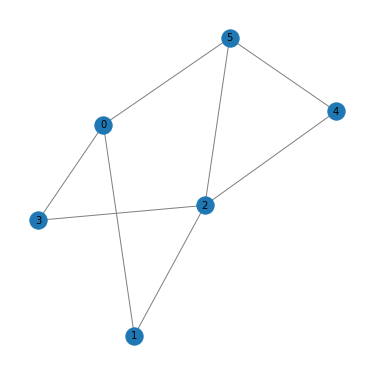

In [24]:
np.random.seed(212)

G = nx.erdos_renyi_graph(6, .5)
plt.figure(figsize=(5,5))
nx.draw(G, with_labels=True, edge_color='gray', node_size=300, font_size=10)


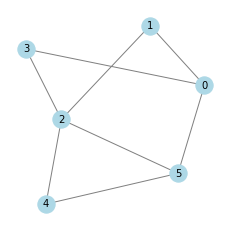

In [49]:
plt.figure(figsize=(3, 3))
layout= nx.kamada_kawai_layout(G)
nx.draw(G, pos=layout, node_color='lightblue', with_labels=True, edge_color='gray', node_size=300, font_size=10)

In [50]:
layout= nx.kamada_kawai_layout(G)
posdf = pd.DataFrame.from_dict(layout, orient='index', columns=['X', 'Y'])
file_path = 'tests/pos_dfs/posdf_ER_1_kamada_kawai.csv'
posdf.to_csv(file_path, index=False)

with open('tests/graph_objects/graph_ER_1_kamada_kawai.pkl', 'wb') as f:
    pickle.dump(G, f)

In [51]:
posdf

,X,Y
0,0.588604,0.255092
1,0.246283,0.886986
2,-0.312247,-0.105385
3,-0.535409,0.638692
4,-0.409376,-1.000000
5,0.422145,-0.675384


In [61]:
posdf_worse = posdf.copy(deep=True)
posdf_worse.at[2, 'X'] = .2
posdf_worse.at[1, 'Y'] = .05
posdf_worse.at[3, 'X'] =0.588604
posdf_worse.at[4, 'X'] = 0
posdf_worse.at[4, 'Y'] = .8

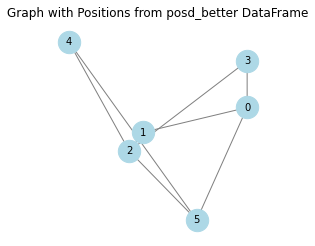

In [62]:
positions = {i: (posdf_worse.loc[i, 'X'], posdf_worse.loc[i, 'Y']) for i in range(len(posdf_worse))}

# Draw the graph
plt.figure(figsize=(3, 3))
nx.draw(G, pos=positions, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, font_size=10)
plt.title('Graph with Positions from posd_better DataFrame')
plt.show()

In [63]:
file_path = 'tests/pos_dfs/posdfworse_ER_1_kamada_kawai.csv'
posdf_worse.to_csv(file_path, index=False)

In [74]:
def calculate_metric(G, posdf):
    print(node_distribution_raw(posdf))
    print(edge_length_sum(G, posdf))
    print(measure_communities_closeness(G, posdf))
    print(measure_graph_symmetry(G, posdf))
    values = [
        node_distribution_raw(posdf),
        edge_length_sum(G, posdf),
        measure_communities_closeness(G, posdf),
        measure_graph_symmetry(G, posdf)
    ]

    # Calculate the min and max values
    min_value = min(values)
    max_value = max(values)

    # Rescale the values to be in the range 0 to 1
    rescaled_values = [(value - min_value) / (max_value - min_value) for value in values]

    # Print the rescaled values
    for i, rescaled_value in enumerate(rescaled_values):
        print(f"Rescaled value {i+1}: {rescaled_value}")

    score = -0.42*node_distribution_raw(posdf) +0.34*edge_length_sum(G, posdf) + 0.39*measure_communities_closeness(G, posdf) -0.47*measure_graph_symmetry(G, posdf)
    score = -0.42*rescaled_values[0] +0.34*rescaled_values[1] + 0.39*rescaled_values[2] -0.47*rescaled_values[3]

    return score

In [75]:
calculate_metric(G, posdf)

13.997659310439426
7.191531301409244
0.02437330280630309
0.9472269049784894
Rescaled value 1: 1.0
Rescaled value 2: 0.512918578685627
Rescaled value 3: 0.0
Rescaled value 4: 0.06604413605132417


-0.2766484271910092

In [76]:
calculate_metric(G, posdf_worse)

26.496380357719097
5.519775408949778
0.08428193394794402
0.9401154320895594
Rescaled value 1: 1.0
Rescaled value 2: 0.20579559366285854
Rescaled value 3: 0.0
Rescaled value 4: 0.03240308605587191


-0.36525894860088787

wyzszy score to lepszy graf
negatywna korelacja ze scorem - im wyzszy komponent tylko nizszy score